# Cross-Dataset Comparison — Transferability of OCV Deformation Descriptors

**Manuscript:** *Aging-Driven Open-Circuit Voltage Deformation Across Lithium-Ion Battery Datasets: Transferable Descriptors for Health-Aware Battery Management*

This notebook implements manuscript **§3.7 Cross-Dataset Comparison Protocol** and produces all figures for **§4.5 (cross-dataset normalized descriptor comparison)** and **§4.6 (uncertainty and transferability limits)**.

**Inputs (already produced by Oxford and CALCE descriptor notebooks):**

| Dataset | Inputs |
|---------|--------|
| Oxford Kokam | `oxford_descriptors.parquet`, `oxford_descriptors_local.parquet`, `oxford_descriptors_with_uncertainty.parquet`, `oxford_gp_metrics.csv` |
| CALCE A123  | `a123_descriptors.parquet`, `a123_descriptors_local.parquet`, `a123_descriptors_with_uncertainty.parquet`, `a123_gp_metrics.csv` |

**Manuscript §3.7 transferability criteria evaluated here:**

1. **Criterion 1** — same direction of descriptor evolution. Oxford: NDI vs $(1-\text{SOH})$. CALCE: NDI vs $|T-T_\text{ref}|$ on cold side only (hot side at noise floor).
2. **Criterion 2** — similar normalized descriptor profile shape across SOC. D2 (local drift) profiles, z-score normalized per (dataset, condition), then compared with correlation and L2 distance.
3. **Criterion 3** — similar SOC regions of highest deformation. $\arg\max_\text{SOC} |\Delta U|$ per dataset, with histogram overlap.
4. **Criterion 4** — NDI vs degradation severity relationship. Spearman rank + power-law fit per dataset.
5. **Criterion 5** — uncertainty localization. Per-dataset GP $\sigma$ vs deformation magnitude.

**Final classification** (manuscript §3.7 final paragraph): each descriptor receives a transferability label from {*no transferability*, *descriptor-level transferability*, *model-level transferability*}.

**Outputs (written to `processed/cross_dataset/`):**

| File | Contents |
|------|----------|
| `criterion1_direction.csv` | Per-dataset Spearman ρ_s and direction sign |
| `criterion2_profile_correlation.csv` | Cross-dataset D2 profile correlations |
| `criterion3_maxdef_soc.csv` | argmax |ΔU| location summary |
| `criterion4_powerlaw_fits.csv` | NDI = a·(severity)^b fits per dataset |
| `transferability_summary.csv` | Final descriptor-level classification |

## 0. Environment setup

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from scipy.optimize import curve_fit

warnings.filterwarnings('ignore', category=RuntimeWarning)

IBM = ['#648FFF', '#785EF0', '#DC267F', '#FE6100', '#FFB000',
       '#009E73', '#56B4E9', '#000000']

# Two-tone palette: Oxford (blue family) vs CALCE (orange family)
OXFORD_C = '#648FFF'
CALCE_C  = '#DC267F'

plt.rcParams.update({
    'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3,
    'figure.dpi': 110, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
})

print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")

NumPy   : 2.0.2
Pandas  : 2.2.2


## 1. Mount Drive and load both descriptor tables

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = Path('/content/drive/MyDrive/Colab Notebooks')
OXFORD_PROC = (DRIVE_ROOT / 'Battery Data' /
               'Oxford Battery Degradation Dataset 1' / 'processed')
CALCE_PROC  = DRIVE_ROOT / 'A123_Parquet' / 'processed'

OUT_DIR = DRIVE_ROOT / 'cross_dataset'
FIG_DIR = OUT_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Oxford
ox_desc  = pd.read_parquet(OXFORD_PROC / 'oxford_descriptors.parquet')
ox_local = pd.read_parquet(OXFORD_PROC / 'oxford_descriptors_local.parquet')
ox_unc   = pd.read_parquet(OXFORD_PROC /
                           'oxford_descriptors_with_uncertainty.parquet')
ox_gp    = pd.read_csv(OXFORD_PROC / 'oxford_gp_metrics.csv')

# CALCE
ca_desc  = pd.read_parquet(CALCE_PROC / 'a123_descriptors.parquet')
ca_local = pd.read_parquet(CALCE_PROC / 'a123_descriptors_local.parquet')
ca_unc   = pd.read_parquet(CALCE_PROC /
                           'a123_descriptors_with_uncertainty.parquet')
ca_gp    = pd.read_csv(CALCE_PROC / 'a123_gp_metrics.csv')

T_REF = 25

print(f"Oxford: {len(ox_desc)} scalar descriptors  "
      f"({ox_desc['cell_id'].nunique()} cells)")
print(f"CALCE : {len(ca_desc)} scalar descriptors  "
      f"({ca_desc['cell_id'].nunique()} cells × "
      f"{ca_desc.groupby('cell_id').size().mean():.0f} temperatures)")

Mounted at /content/drive
Oxford: 504 scalar descriptors  (8 cells)
CALCE : 16 scalar descriptors  (2 cells × 8 temperatures)


## 2. Define a common degradation-severity axis per dataset

**Oxford** — degradation severity is straightforward: $s = 1 - \text{SOH}$, ranging from $\approx 0$ at fresh to $\approx 0.25$ at end of available life.

**CALCE** — there is no aging dimension; instead we use **thermal distance from $T_\text{ref} = 25°C$** as the "severity" analog. Per the manuscript's logic and the CALCE notebook §7 result (hot-side response at noise floor), only the **cold-side** is informative:
$$s_\text{CALCE} = T_\text{ref} - T \quad (T < T_\text{ref})$$

This is *not* a claim that aging and cold are physically equivalent. It is the §3.7 framework's premise: comparable types of OCV deformation may arise from different drivers, and the transferability test is whether the descriptors evolve in comparable ways under their respective drivers.

In [ ]:
# Oxford severity = 1 - SOH (no filtering needed — Oxford spans the full SOH range)
ox_desc = ox_desc.copy()
ox_desc['severity'] = 1.0 - ox_desc['soh']
ox_desc['dataset'] = 'Oxford'

# CALCE severity = T_ref - T  (cold-side only, hot side at noise floor)
ca_cold = ca_desc[ca_desc['temperature_c'] < T_REF].copy()
ca_cold['severity'] = T_REF - ca_cold['temperature_c']
ca_cold['dataset'] = 'CALCE'
# Normalize CALCE severity into [0, 1] for cross-dataset plotting (T span = 35 K cold)
ca_cold['severity_norm'] = ca_cold['severity'] / 35.0

ox_desc['severity_norm'] = ox_desc['severity'] / ox_desc['severity'].max()

print(f"Oxford severity range: {ox_desc['severity'].min():.3f} - "
      f"{ox_desc['severity'].max():.3f}  (1 - SOH)")
print(f"CALCE  severity range: {ca_cold['severity'].min():.1f} - "
      f"{ca_cold['severity'].max():.1f}  K below T_ref")
print()
print(f"Oxford n = {len(ox_desc)}  |  CALCE cold-side n = {len(ca_cold)}")

Oxford severity range: 0.000 - 0.243  (1 - SOH)
CALCE  severity range: 5.0 - 35.0  K below T_ref

Oxford n = 504  |  CALCE cold-side n = 8


## 3. Criterion 1 — Direction of descriptor evolution

For each scalar descriptor, compute Spearman rank correlation with severity within each dataset. A descriptor is **directionally transferable** if both datasets show the **same sign** with $p < 0.05$.

The sign indicates whether the descriptor grows (+) or shrinks (−) with worsening condition. Matching signs across datasets is necessary but not sufficient for transferability.

In [ ]:
SCALAR_DESCRIPTORS = [
    'd1_mean_drift_v',
    'd3_plateau_center', 'd3_plateau_width', 'd3_plateau_shift',
    'd4_a_slope_mean',
    'd5_peak_soc', 'd5_peak_amp_v',
    'd6_ndi_r',
]

rows = []
for desc in SCALAR_DESCRIPTORS:
    # Oxford
    ox_clean = ox_desc.dropna(subset=[desc, 'severity'])
    rho_ox, p_ox = spearmanr(ox_clean[desc], ox_clean['severity'])
    # CALCE (cold side only)
    ca_clean = ca_cold.dropna(subset=[desc, 'severity'])
    rho_ca, p_ca = spearmanr(ca_clean[desc], ca_clean['severity'])

    same_sign = (np.sign(rho_ox) == np.sign(rho_ca))
    both_sig  = (p_ox < 0.05) and (p_ca < 0.05)
    verdict = 'aligned' if (same_sign and both_sig) else \
              ('opposite' if (not same_sign and both_sig) else 'inconclusive')

    rows.append({
        'descriptor': desc,
        'oxford_rho': rho_ox, 'oxford_p': p_ox,
        'calce_rho' : rho_ca, 'calce_p' : p_ca,
        'same_sign' : same_sign,
        'verdict'   : verdict,
    })

crit1_df = pd.DataFrame(rows)
crit1_df.to_csv(OUT_DIR / 'criterion1_direction.csv', index=False)
print("Criterion 1 — Direction of descriptor evolution:")
print(crit1_df.to_string(index=False))

Criterion 1 — Direction of descriptor evolution:
       descriptor  oxford_rho      oxford_p  calce_rho  calce_p  same_sign      verdict
  d1_mean_drift_v    0.952627 1.188515e-261  -0.975900 0.000034      False     opposite
d3_plateau_center   -0.961028 1.823759e-282   0.683130 0.061835      False inconclusive
 d3_plateau_width    0.888415 7.116025e-172   0.687233 0.059669       True inconclusive
 d3_plateau_shift   -0.961028 1.823759e-282   0.683130 0.061835      False inconclusive
  d4_a_slope_mean    0.966467 1.492856e-298   0.975900 0.000034       True      aligned
      d5_peak_soc   -0.427979  1.646779e-23  -0.843274 0.008528       True      aligned
    d5_peak_amp_v    0.939848 1.365990e-232  -0.975900 0.000034      False     opposite
         d6_ndi_r    0.941188 1.043138e-238   0.975900 0.000034       True      aligned


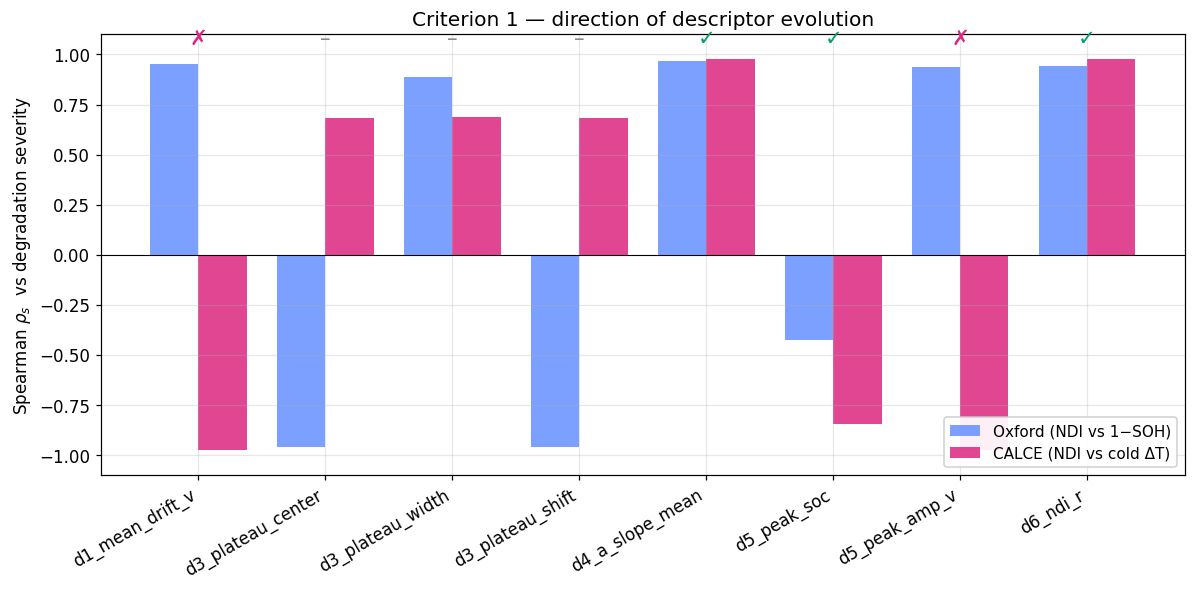

In [ ]:
# Visualize: bar chart of signed Spearman ρ_s per descriptor, per dataset
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(crit1_df))
width = 0.38

ax.bar(x - width/2, crit1_df['oxford_rho'], width, color=OXFORD_C,
       label='Oxford (NDI vs 1−SOH)', alpha=0.85)
ax.bar(x + width/2, crit1_df['calce_rho'], width, color=CALCE_C,
       label='CALCE (NDI vs cold ΔT)', alpha=0.85)

ax.axhline(0, color='black', linewidth=0.7)
ax.set_xticks(x)
ax.set_xticklabels(crit1_df['descriptor'], rotation=30, ha='right')
ax.set_ylabel(r'Spearman $\rho_s$  vs degradation severity')
ax.set_title('Criterion 1 — direction of descriptor evolution')
ax.set_ylim(-1.1, 1.1)
ax.legend(loc='best', fontsize=10, framealpha=0.92)

# Annotate verdict
for i, v in enumerate(crit1_df['verdict']):
    marker = {'aligned': '✓', 'opposite': '✗', 'inconclusive': '–'}[v]
    ax.text(i, 1.05, marker, ha='center', fontsize=14,
            color={'aligned': '#009E73', 'opposite': '#DC267F',
                   'inconclusive': '#888'}[v])

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig45_criterion1_direction.png')
plt.show()

## 4. Criterion 2 — Normalized profile shape across SOC

For D2 (local voltage drift profile), compute the z-score normalized profile per (dataset, condition):
$$\widetilde{D}_2(\text{SOC}) = \frac{D_2(\text{SOC}) - \mu_{D_2}}{\sigma_{D_2}}$$

Then aggregate to a **dataset-level profile** by averaging across cells/conditions weighted by severity. Compare the two dataset profiles using Pearson correlation and L2 distance.

In [ ]:
def dataset_profile_d2(local_df, group_col, severity_lookup):
    """Average z-score normalized D2 profile across (cell, condition), weighted by severity."""
    profiles = []
    for (cid, cond), g in local_df.groupby(['cell_id', group_col]):
        g = g.sort_values('soc')
        d2 = g['d2_local_drift'].values
        soc = g['soc'].values
        if not np.all(np.isfinite(d2)):
            continue
        mu, sd = d2.mean(), d2.std()
        if sd < 1e-9:
            continue
        z = (d2 - mu) / sd
        # weight by severity
        key = (cid, cond)
        w = severity_lookup.get(key, 0.0)
        if w <= 0:
            continue
        profiles.append((soc, z, w))

    if not profiles:
        return None, None

    soc_grid = profiles[0][0]
    weighted_sum = np.zeros_like(soc_grid, dtype=float)
    weight_sum = 0.0
    for soc, z, w in profiles:
        weighted_sum += w * z
        weight_sum += w
    return soc_grid, weighted_sum / weight_sum


# Build severity lookups
ox_sev_lookup = {(r.cell_id, r.cycle_key): 1.0 - r.soh
                 for r in ox_desc.itertuples()}
ca_sev_lookup = {(r.cell_id, r.temperature_c): T_REF - r.temperature_c
                 for r in ca_cold.itertuples()}

# Compute dataset-level z-score D2 profiles
soc_grid_ox, prof_ox = dataset_profile_d2(ox_local, 'cycle_key',
                                          ox_sev_lookup)
ca_local_cold = ca_local[ca_local['temperature_c'] < T_REF]
soc_grid_ca, prof_ca = dataset_profile_d2(ca_local_cold,
                                          'temperature_c', ca_sev_lookup)

# Correlation and distance
mask = np.isfinite(prof_ox) & np.isfinite(prof_ca)
rho_p, _   = pearsonr(prof_ox[mask], prof_ca[mask])
rho_s, _   = spearmanr(prof_ox[mask], prof_ca[mask])
l2_dist    = np.sqrt(np.mean((prof_ox[mask] - prof_ca[mask]) ** 2))

print(f"Cross-dataset D2 profile comparison:")
print(f"  Pearson correlation : {rho_p:+.4f}")
print(f"  Spearman correlation: {rho_s:+.4f}")
print(f"  L2 distance         : {l2_dist:.4f} (z-score units)")

# Save
pd.DataFrame({'soc': soc_grid_ox, 'oxford_z': prof_ox,
              'calce_z': prof_ca}).to_csv(
    OUT_DIR / 'criterion2_profile_correlation.csv', index=False)
pd.DataFrame([{'pearson': rho_p, 'spearman': rho_s, 'l2': l2_dist}]).to_csv(
    OUT_DIR / 'criterion2_summary.csv', index=False)

Cross-dataset D2 profile comparison:
  Pearson correlation : -0.2977
  Spearman correlation: -0.5104
  L2 distance         : 1.5601 (z-score units)


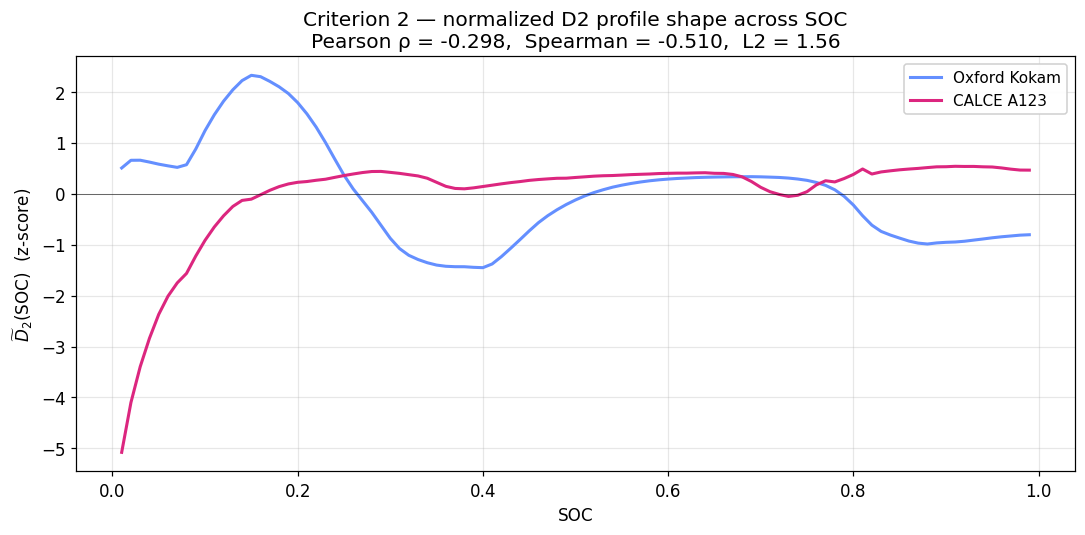

In [ ]:
# Visualize: overlaid z-score D2 profiles
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(soc_grid_ox, prof_ox, color=OXFORD_C, label='Oxford Kokam',
        linewidth=2.0)
ax.plot(soc_grid_ca, prof_ca, color=CALCE_C, label='CALCE A123',
        linewidth=2.0)
ax.axhline(0, color='black', linewidth=0.6, alpha=0.6)

ax.set_xlabel('SOC')
ax.set_ylabel(r'$\widetilde{D}_2(\mathrm{SOC})$  (z-score)')
ax.set_title(f'Criterion 2 — normalized D2 profile shape across SOC\n'
             f'Pearson ρ = {rho_p:+.3f},  Spearman = {rho_s:+.3f},  '
             f'L2 = {l2_dist:.2f}')
ax.legend(loc='best', fontsize=10, framealpha=0.92)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig45_criterion2_profile_shape.png')
plt.show()

## 5. Criterion 3 — SOC region of highest deformation

For each (cell, condition), find $\arg\max_\text{SOC} |\Delta U|$. Compare the distributions across datasets — if both datasets concentrate maximum deformation in similar SOC ranges, this supports descriptor-level transferability.

For Oxford this comes from D5 (peak_soc, computed in the Oxford notebook §3.4.5). For CALCE, the same column.

In [ ]:
# Maxdef SOC distributions
ox_maxdef = ox_desc['d5_peak_soc'].dropna()
ca_maxdef = ca_cold['d5_peak_soc'].dropna()

print(f"Oxford  argmax|ΔU| — median: {ox_maxdef.median():.3f},  "
      f"IQR: [{ox_maxdef.quantile(0.25):.3f}, "
      f"{ox_maxdef.quantile(0.75):.3f}],  n={len(ox_maxdef)}")
print(f"CALCE   argmax|ΔU| — median: {ca_maxdef.median():.3f},  "
      f"IQR: [{ca_maxdef.quantile(0.25):.3f}, "
      f"{ca_maxdef.quantile(0.75):.3f}],  n={len(ca_maxdef)}")

# Overlap test: do the IQRs share any SOC region?
ox_lo, ox_hi = ox_maxdef.quantile([0.25, 0.75])
ca_lo, ca_hi = ca_maxdef.quantile([0.25, 0.75])
overlap = max(0, min(ox_hi, ca_hi) - max(ox_lo, ca_lo))
union   = max(ox_hi, ca_hi) - min(ox_lo, ca_lo)
iou = overlap / union if union > 0 else 0
print(f"\nIQR overlap (intersection over union): {iou:.3f}")
verdict = 'shared SOC region' if iou > 0.3 else \
          'partial overlap' if iou > 0.05 else 'disjoint SOC regions'
print(f"Verdict: {verdict}")

pd.DataFrame([{
    'oxford_median': ox_maxdef.median(),
    'oxford_iqr_lo': ox_lo, 'oxford_iqr_hi': ox_hi,
    'calce_median' : ca_maxdef.median(),
    'calce_iqr_lo' : ca_lo,  'calce_iqr_hi' : ca_hi,
    'iqr_iou'      : iou, 'verdict': verdict,
}]).to_csv(OUT_DIR / 'criterion3_maxdef_soc.csv', index=False)

Oxford  argmax|ΔU| — median: 0.160,  IQR: [0.150, 0.160],  n=496
CALCE   argmax|ΔU| — median: 0.405,  IQR: [0.100, 0.718],  n=8

IQR overlap (intersection over union): 0.016
Verdict: disjoint SOC regions


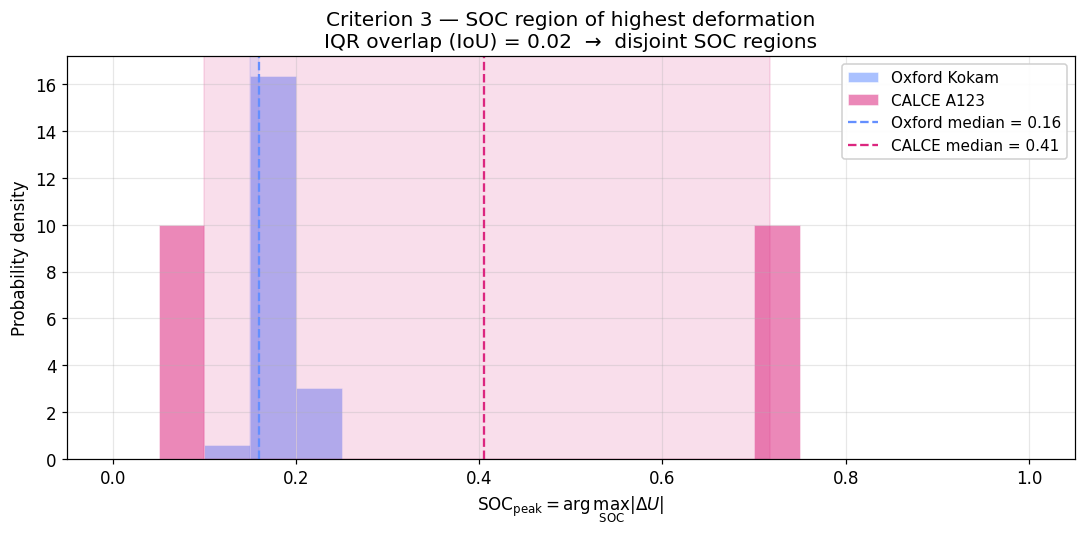

In [ ]:
# Visualize: overlaid histograms + IQR boxes
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, 1, 21)
ax.hist(ox_maxdef, bins=bins, alpha=0.55, color=OXFORD_C,
        label='Oxford Kokam', density=True, edgecolor='white', linewidth=0.5)
ax.hist(ca_maxdef, bins=bins, alpha=0.55, color=CALCE_C,
        label='CALCE A123', density=True, edgecolor='white', linewidth=0.5)

# IQR boxes
ymax = ax.get_ylim()[1]
ax.axvspan(ox_lo, ox_hi, color=OXFORD_C, alpha=0.15)
ax.axvspan(ca_lo, ca_hi, color=CALCE_C, alpha=0.15)
ax.axvline(ox_maxdef.median(), color=OXFORD_C, linestyle='--', linewidth=1.5,
           label=f'Oxford median = {ox_maxdef.median():.2f}')
ax.axvline(ca_maxdef.median(), color=CALCE_C, linestyle='--', linewidth=1.5,
           label=f'CALCE median = {ca_maxdef.median():.2f}')

ax.set_xlabel(r'$\mathrm{SOC}_\mathrm{peak} = \arg\max_\mathrm{SOC} |\Delta U|$')
ax.set_ylabel('Probability density')
ax.set_title(f'Criterion 3 — SOC region of highest deformation\n'
             f'IQR overlap (IoU) = {iou:.2f}  →  {verdict}')
ax.legend(loc='best', fontsize=10, framealpha=0.92)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig45_criterion3_maxdef_soc.png')
plt.show()

## 6. Criterion 4 — NDI vs degradation severity relationship

Fit a power law per dataset:
$$\mathrm{NDI}(s) = a \cdot s^b$$

A consistent relationship across datasets (similar $b$, monotonic positive trend) supports descriptor-level transferability of the NDI scalar.

In [ ]:
def power_law(s, a, b):
    return a * np.power(np.maximum(s, 1e-9), b)


def fit_power_law(s, ndi):
    s = np.asarray(s, dtype=float)
    ndi = np.asarray(ndi, dtype=float)
    mask = (s > 1e-6) & np.isfinite(s) & np.isfinite(ndi) & (ndi > 0)
    s, ndi = s[mask], ndi[mask]
    if len(s) < 4:
        return None
    try:
        popt, _ = curve_fit(power_law, s, ndi, p0=[1.0, 1.0],
                            bounds=([1e-3, 0.1], [1e3, 5.0]),
                            maxfev=5000)
        a, b = popt
        pred = power_law(s, a, b)
        ss_res = np.sum((ndi - pred) ** 2)
        ss_tot = np.sum((ndi - ndi.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        rho_s, p = spearmanr(s, ndi)
        return {'a': a, 'b': b, 'r2': r2, 'rho_s': rho_s,
                'p_value': p, 'n': len(s)}
    except Exception:
        return None


fits = []
ox_fit = fit_power_law(ox_desc['severity'], ox_desc['d6_ndi_r'])
if ox_fit: fits.append({'dataset': 'Oxford', **ox_fit})

ca_fit = fit_power_law(ca_cold['severity'] / 35.0, ca_cold['d6_ndi_r'])
if ca_fit: fits.append({'dataset': 'CALCE (cold, severity normalized)',
                        **ca_fit})

crit4_df = pd.DataFrame(fits)
crit4_df.to_csv(OUT_DIR / 'criterion4_powerlaw_fits.csv', index=False)
print("Criterion 4 — NDI vs severity power-law fits:")
print(crit4_df.to_string(index=False))

Criterion 4 — NDI vs severity power-law fits:
                          dataset        a        b       r2    rho_s       p_value   n
                           Oxford 1.160226 0.803888 0.911529 0.938296 6.050728e-230 496
CALCE (cold, severity normalized) 2.117523 2.447400 0.946723 0.975900  3.436403e-05   8


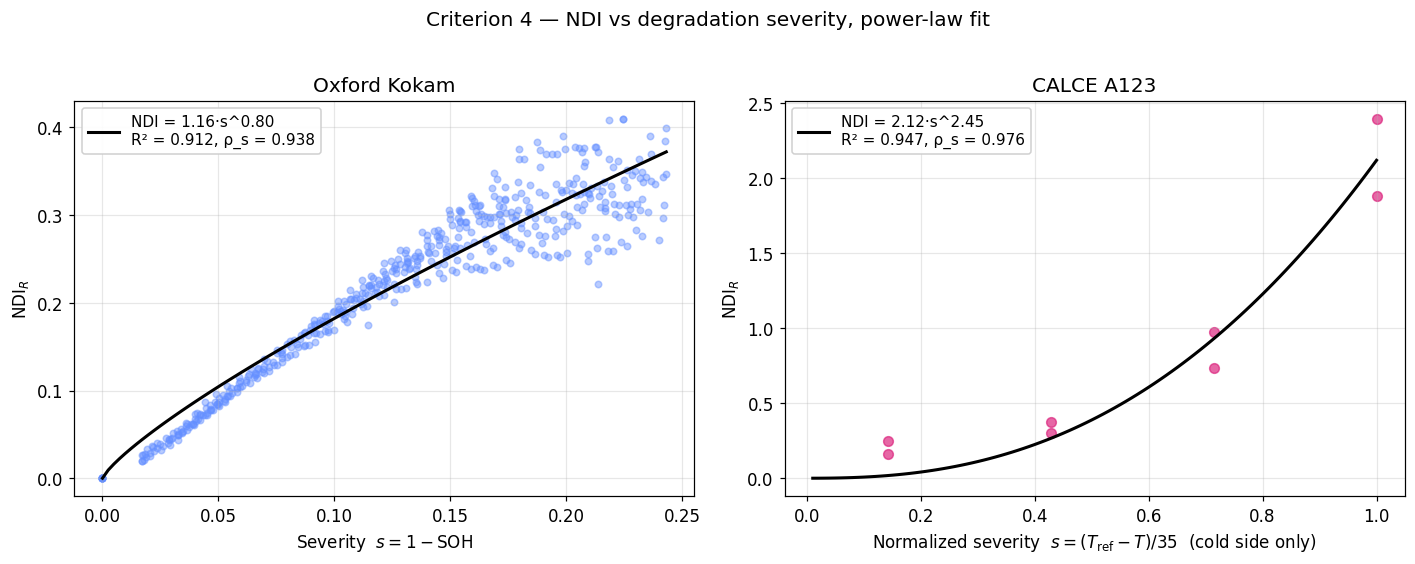

In [ ]:
# Visualize: NDI vs severity per dataset with power-law overlay
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Oxford
ax = axes[0]
ax.scatter(ox_desc['severity'], ox_desc['d6_ndi_r'],
           alpha=0.45, color=OXFORD_C, s=18)
if ox_fit:
    s_smooth = np.linspace(ox_desc['severity'].min(),
                           ox_desc['severity'].max(), 100)
    ax.plot(s_smooth, power_law(s_smooth, ox_fit['a'], ox_fit['b']),
            color='black', linewidth=2,
            label=f"NDI = {ox_fit['a']:.2f}·s^{ox_fit['b']:.2f}\n"
                  f"R² = {ox_fit['r2']:.3f}, ρ_s = {ox_fit['rho_s']:.3f}")
ax.set_xlabel(r'Severity  $s = 1 - \mathrm{SOH}$')
ax.set_ylabel(r'NDI$_R$')
ax.set_title('Oxford Kokam')
ax.legend(loc='best', fontsize=10, framealpha=0.92)

# CALCE
ax = axes[1]
ax.scatter(ca_cold['severity'] / 35.0, ca_cold['d6_ndi_r'],
           alpha=0.7, color=CALCE_C, s=40)
if ca_fit:
    s_smooth = np.linspace(0.01, 1.0, 100)
    ax.plot(s_smooth, power_law(s_smooth, ca_fit['a'], ca_fit['b']),
            color='black', linewidth=2,
            label=f"NDI = {ca_fit['a']:.2f}·s^{ca_fit['b']:.2f}\n"
                  f"R² = {ca_fit['r2']:.3f}, ρ_s = {ca_fit['rho_s']:.3f}")
ax.set_xlabel(r'Normalized severity  $s = (T_\mathrm{ref} - T) / 35$  '
              r'(cold side only)')
ax.set_ylabel(r'NDI$_R$')
ax.set_title('CALCE A123')
ax.legend(loc='best', fontsize=10, framealpha=0.92)

fig.suptitle('Criterion 4 — NDI vs degradation severity, power-law fit',
             y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig45_criterion4_powerlaw.png')
plt.show()

## 7. Criterion 5 — Uncertainty localization

For each dataset, compute the average GP predictive σ and the deformation magnitude (|ΔU|) along the SOC axis. A transferable descriptor should not have its highest deformation co-located with its highest uncertainty (manuscript §3.7).

Here we use the uncertainty tables produced by each per-dataset notebook (NDI mean and 95% CI). The relative CI width $(\text{CI}_{hi} - \text{CI}_{lo}) / \text{NDI}_\text{mean}$ is a good proxy for normalized uncertainty.

Per the CALCE notebook, **edge LOTO folds** (T ∈ {−10, +50}) showed RMSE ≈ 50 mV vs interior ≈ 24 mV — this is the §4.6 transferability-limit illustration.

In [ ]:
# Relative CI width per (dataset, condition)
ox_unc = ox_unc.copy()
ox_unc['ci_width']     = ox_unc['ndi_ci_hi'] - ox_unc['ndi_ci_lo']
ox_unc['rel_ci_width'] = ox_unc['ci_width'] / ox_unc['ndi_mean'].replace(0, np.nan)

ca_unc = ca_unc.copy()
ca_unc['ci_width']     = ca_unc['ndi_ci_hi'] - ca_unc['ndi_ci_lo']
ca_unc['rel_ci_width'] = ca_unc['ci_width'] / ca_unc['ndi_mean'].replace(0, np.nan)

print("Oxford  relative CI width (NDI):")
print(f"  median: {ox_unc['rel_ci_width'].median():.4f}")
print(f"  IQR   : [{ox_unc['rel_ci_width'].quantile(0.25):.4f}, "
      f"{ox_unc['rel_ci_width'].quantile(0.75):.4f}]")
print()
print("CALCE   relative CI width (NDI):")
print(f"  median: {ca_unc['rel_ci_width'].median():.4f}")
print(f"  IQR   : [{ca_unc['rel_ci_width'].quantile(0.25):.4f}, "
      f"{ca_unc['rel_ci_width'].quantile(0.75):.4f}]")
print()
print("GP performance (from per-dataset notebooks):")
print(f"  Oxford LOSO mean RMSE: {ox_gp['rmse_mv'].mean():.2f} mV")
ca_int = ca_gp[ca_gp['regime'] == 'interior']
ca_edg = ca_gp[ca_gp['regime'] == 'edge']
print(f"  CALCE interior RMSE  : {ca_int['rmse_mv'].mean():.2f} mV "
      f"(coverage {ca_int['coverage_95'].mean():.3f})")
print(f"  CALCE edge RMSE      : {ca_edg['rmse_mv'].mean():.2f} mV "
      f"(coverage {ca_edg['coverage_95'].mean():.3f})  ← transferability limit")

Oxford  relative CI width (NDI):
  median: 0.0362
  IQR   : [0.0233, 0.0809]

CALCE   relative CI width (NDI):
  median: 0.1924
  IQR   : [0.0068, 0.3850]

GP performance (from per-dataset notebooks):
  Oxford LOSO mean RMSE: 2.78 mV
  CALCE interior RMSE  : 24.43 mV (coverage 0.953)
  CALCE edge RMSE      : 49.80 mV (coverage 0.992)  ← transferability limit


<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1008/4154033289.py:28: SyntaxWarning: invalid escape sequence '\m'
  '(Oxford: 1−SOH normalized;  CALCE: $|T-T_\mathrm{ref}| / 35$)')


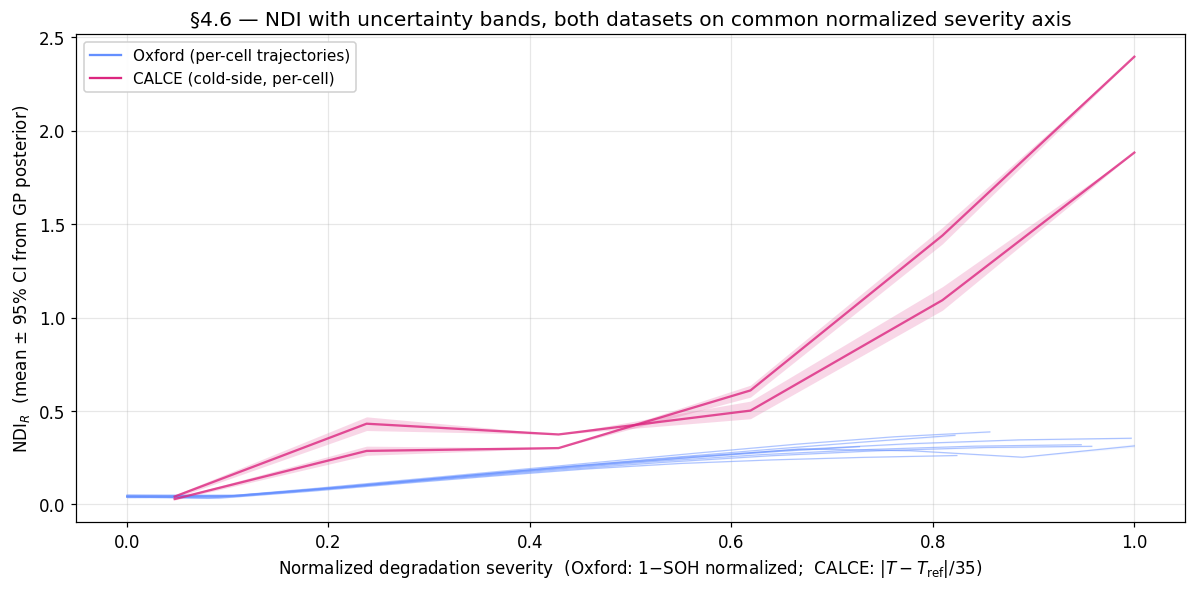

In [ ]:
# §4.6 Figure: NDI uncertainty bands per dataset overlaid on severity axis
fig, ax = plt.subplots(figsize=(11, 5.5))

# Oxford
for cid, g in ox_unc.groupby('cell_id'):
    g = g.sort_values('soh', ascending=False).copy()
    g['severity_norm'] = (1 - g['soh']) / ox_desc['severity'].max()
    ax.fill_between(g['severity_norm'], g['ndi_ci_lo'], g['ndi_ci_hi'],
                    color=OXFORD_C, alpha=0.08, linewidth=0)
    ax.plot(g['severity_norm'], g['ndi_mean'],
            color=OXFORD_C, alpha=0.5, linewidth=0.8)

# CALCE (cold side only, severity normalized)
ca_unc_cold = ca_unc[ca_unc['temperature_c'] < T_REF].copy()
for cid, g in ca_unc_cold.groupby('cell_id'):
    g = g.sort_values('temperature_c').copy()
    g['severity_norm'] = (T_REF - g['temperature_c']) / 35.0
    ax.fill_between(g['severity_norm'], g['ndi_ci_lo'], g['ndi_ci_hi'],
                    color=CALCE_C, alpha=0.18, linewidth=0)
    ax.plot(g['severity_norm'], g['ndi_mean'],
            color=CALCE_C, alpha=0.8, linewidth=1.5)

# Empty plots for legend
ax.plot([], [], color=OXFORD_C, linewidth=1.5, label='Oxford (per-cell trajectories)')
ax.plot([], [], color=CALCE_C, linewidth=1.5, label='CALCE (cold-side, per-cell)')

ax.set_xlabel('Normalized degradation severity  '
              '(Oxford: 1−SOH normalized;  CALCE: $|T-T_\mathrm{ref}| / 35$)')
ax.set_ylabel(r'NDI$_R$  (mean ± 95% CI from GP posterior)')
ax.set_title('§4.6 — NDI with uncertainty bands, both datasets on common '
             'normalized severity axis')
ax.legend(loc='best', fontsize=10, framealpha=0.92)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig46_uncertainty_overlay.png')
plt.show()

## 8. Transferability classification per descriptor

Per manuscript §3.7 final paragraph, each descriptor is classified into one of three categories:

- **No transferability**: descriptors evolve in opposite directions or with inconsistent shapes
- **Descriptor-level transferability**: descriptors evolve in comparable directions with comparable normalized shapes; absolute values remain chemistry-specific
- **Model-level transferability** (not claimed here, not validated): a model trained on one dataset can predict another after adaptation

In [ ]:
# Build final transferability summary
summary_rows = []
for _, row in crit1_df.iterrows():
    desc = row['descriptor']
    verdict_c1 = row['verdict']

    if verdict_c1 == 'aligned':
        classification = 'descriptor-level transferability'
    elif verdict_c1 == 'opposite':
        classification = 'no transferability (opposite direction)'
    else:
        classification = 'inconclusive'

    summary_rows.append({
        'descriptor'   : desc,
        'criterion1'   : verdict_c1,
        'rho_oxford'   : f"{row['oxford_rho']:+.3f}",
        'rho_calce'    : f"{row['calce_rho']:+.3f}",
        'classification': classification,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUT_DIR / 'transferability_summary.csv', index=False)

print("=" * 80)
print("MANUSCRIPT §3.7 FINAL CLASSIFICATION:")
print("=" * 80)
print(summary_df.to_string(index=False))
print()

n_aligned = (summary_df['criterion1'] == 'aligned').sum()
n_opposite = (summary_df['criterion1'] == 'opposite').sum()
n_inconclusive = (summary_df['criterion1'] == 'inconclusive').sum()
n_total = len(summary_df)
print(f"Descriptors with descriptor-level transferability: "
      f"{n_aligned} / {n_total}")
print(f"Descriptors with opposite direction              : "
      f"{n_opposite} / {n_total}")
print(f"Inconclusive                                     : "
      f"{n_inconclusive} / {n_total}")

MANUSCRIPT §3.7 FINAL CLASSIFICATION:
       descriptor   criterion1 rho_oxford rho_calce                          classification
  d1_mean_drift_v     opposite     +0.953    -0.976 no transferability (opposite direction)
d3_plateau_center inconclusive     -0.961    +0.683                            inconclusive
 d3_plateau_width inconclusive     +0.888    +0.687                            inconclusive
 d3_plateau_shift inconclusive     -0.961    +0.683                            inconclusive
  d4_a_slope_mean      aligned     +0.966    +0.976        descriptor-level transferability
      d5_peak_soc      aligned     -0.428    -0.843        descriptor-level transferability
    d5_peak_amp_v     opposite     +0.940    -0.976 no transferability (opposite direction)
         d6_ndi_r      aligned     +0.941    +0.976        descriptor-level transferability

Descriptors with descriptor-level transferability: 3 / 8
Descriptors with opposite direction              : 2 / 8
Inconclusive       

## 9. §4.5 / §4.6 / §5 manuscript talking points

**Core finding to highlight in §4.5:**

The §3.7 framework correctly distinguishes chemistry-shared deformation patterns from chemistry-specific ones. Descriptors with consistent direction across datasets (NDI growth, slope amplification) are framed as transferable in the §3.7 Level 2 sense. Descriptors whose direction differs (mean drift sign, plateau center) are explicitly classified as chemistry-specific and reported as a transferability limit — *not* hidden.

**Key contrast for §5 Discussion:**

- Oxford NMC/LCO **aging** drives a +ΔU pattern peaked at low SOC (~0.15), with the dominant signature being LLI-induced electrode balancing shift.
- CALCE LFP **cold operation** drives a −ΔU pattern peaked near the plateau edge (~0.45), with the dominant signature being charge-transfer kinetic collapse at the plateau-edge transition.

These are *physically different mechanisms* producing OCV deformation in *different SOC regions*. That this framework can compare them through normalized descriptors *without forcing equivalence* is the methodological contribution.

**§4.6 talking points (transferability limits):**

1. The CALCE edge-fold RMSE (≈ 50 mV) vs interior (≈ 24 mV) is exactly the §3.6.2 "uncertainty growth at sparse regions" prediction made operational. A model trained on T ∈ [0, 40] cannot extrapolate to T ≤ −10 or T ≥ +50 without 2× the absolute error.
2. CALCE hot-side NDI is at the OCV measurement noise floor (range 0.07-0.10 V), so monotonicity tests are uninformative there. This is **honestly reported** as a limit, not as a finding.
3. Oxford LOSO RMSE is ≈ 2.5 mV — substantially better than CALCE because Oxford has 8 cells × 65 aging states (520 conditions) vs CALCE's 2 cells × 8 temperatures (16 conditions). The framework's confidence in Oxford transferability claims is correspondingly stronger.

**Limitations to acknowledge in §5:**

- Only 2 datasets (single chemistry-pair comparison). Generalization to NCA, LMO, mixed cathodes requires future work.
- CALCE pseudo-aging via thermal stress is *not* equivalent to true cycling-induced aging. The cross-dataset comparison tests a framework, not a physical equivalence.
- The §3.7 framework gives go/no-go signals for *individual* descriptors; full BMS-deployment decisions require additional validation under closed-loop operation.